In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_parquet('../data/cl_data.parquet')
df.tail(10)

/home/joe/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/joe/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,id_transaccion,id_vehiculo,id_ubicacion,id_cliente,fecha,unidades,venta_bruta,marca,modelo,anio,mes,dia
480870,ST-2536311,13,4,13867,2022-08-27,1,772838.0,Jeep,Grand Cherokee,2022,August,Saturday
480871,ST-2536312,7,7,8615,2023-04-23,1,1006856.0,Fiat,Argo,2023,April,Sunday
480872,ST-2536313,2,4,14768,2024-08-23,1,704422.0,Alfa Romeo,Stelvio,2024,August,Friday
480873,ST-2536314,13,1,13891,2024-11-23,1,658685.0,Jeep,Grand Cherokee,2024,November,Saturday
480874,ST-2536315,1,4,8974,2024-07-07,1,672403.0,Alfa Romeo,Giulia,2024,July,Sunday
480875,ST-2536316,13,2,627,2022-11-02,1,810925.0,Jeep,Grand Cherokee,2022,November,Wednesday
480876,ST-2536317,3,5,10602,2023-06-13,1,840915.0,Alfa Romeo,Tonale,2023,June,Tuesday
480877,ST-2536318,5,4,10262,2024-11-13,1,511234.0,Dodge,Durango,2024,November,Wednesday
480878,ST-2536319,4,4,13095,2022-02-02,1,605180.0,Dodge,Attitude,2022,February,Wednesday
480879,ST-2536320,20,5,2739,2023-06-26,1,644996.0,RAM,1500,2023,June,Monday


In [5]:
matriz = df[['venta_bruta','unidades']].corr(method = 'pearson', min_periods=1, numeric_only=True)
matriz.tail()

,venta_bruta,unidades
venta_bruta,1.000000,0.688621
unidades,0.688621,1.000000


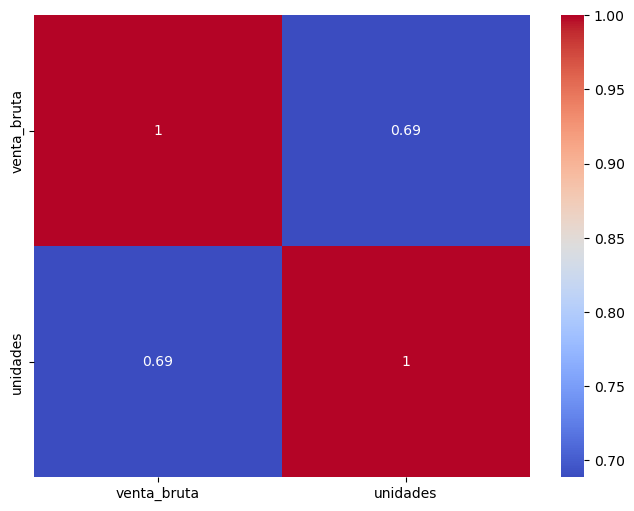

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,6))
sns.heatmap(matriz, annot=True, cmap='coolwarm')
plt.show()

In [7]:
df['periodo'] = df['fecha'].dt.to_period('M')
df_1 = df.groupby(['id_cliente'])['periodo'].min().reset_index()
df_1 = df_1.rename(columns={'periodo': 'cohorte'})
df_2 = df.merge(df_1[['id_cliente','cohorte']], on='id_cliente', how='outer' )
df_2['diff'] = df_2['periodo'].astype(int) - df_2['cohorte'].astype(int) 
df_2.head(80)

,id_transaccion,id_vehiculo,id_ubicacion,id_cliente,fecha,unidades,venta_bruta,marca,modelo,anio,mes,dia,periodo,cohorte,diff
0,ST-2029357,3,2,1,2022-11-11,1,934991.0,Alfa Romeo,Tonale,2022,November,Friday,2022-11,2022-01,10
1,ST-2075220,1,1,1,2023-12-27,1,386952.0,Alfa Romeo,Giulia,2023,December,Wednesday,2023-12,2022-01,23
2,ST-2093405,16,4,1,2025-01-01,1,758650.0,Peugeot,2008,2025,January,Wednesday,2025-01,2022-01,36
3,ST-2097935,2,2,1,2025-01-22,1,375160.0,Alfa Romeo,Stelvio,2025,January,Wednesday,2025-01,2022-01,36
4,ST-2099643,11,4,1,2022-08-26,1,583644.0,Jeep,Compass,2022,August,Friday,2022-08,2022-01,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,ST-2376887,20,4,2,2023-11-08,1,496110.0,RAM,1500,2023,November,Wednesday,2023-11,2022-06,17
76,ST-2405155,2,3,2,2023-12-03,1,384117.0,Alfa Romeo,Stelvio,2023,December,Sunday,2023-12,2022-06,18
77,ST-2410519,2,1,2,2023-10-21,1,741585.0,Alfa Romeo,Stelvio,2023,October,Saturday,2023-10,2022-06,16
78,ST-2426572,1,2,2,2024-11-18,1,686198.0,Alfa Romeo,Giulia,2024,November,Monday,2024-11,2022-06,29


In [8]:
# Crear la tabla pivote con el conteo de clientes únicos
matriz_cohortes = df_2.pivot_table(index='cohorte',columns='diff',values='id_cliente',aggfunc='nunique')

# Mostrar las primeras filas
#matriz_cohortes.head()

In [9]:
df['venta_base'] = (df['venta_bruta'] / 1.16).round(2)
df['iva'] = df['venta_bruta'] - df['venta_base']
df.head()

,id_transaccion,id_vehiculo,id_ubicacion,id_cliente,fecha,unidades,venta_bruta,marca,modelo,anio,mes,dia,periodo,venta_base,iva
0,ST-2000000,1,1,2536,2024-12-01,1,679237.0,Alfa Romeo,Giulia,2024,December,Sunday,2024-12,585549.14,93687.86
1,ST-2000001,2,2,4867,2022-09-22,1,419582.0,Alfa Romeo,Stelvio,2022,September,Thursday,2022-09,361708.62,57873.38
2,ST-2000002,3,1,4669,2024-12-01,1,834373.0,Alfa Romeo,Tonale,2024,December,Sunday,2024-12,719287.07,115085.93
3,ST-2000003,4,3,899,2024-04-27,1,945477.0,Dodge,Attitude,2024,April,Saturday,2024-04,815066.38,130410.62
4,ST-2000004,5,4,2471,2025-11-13,1,433661.0,Dodge,Durango,2025,November,Thursday,2025-11,373845.69,59815.31


In [18]:
def ranking(lista):
    unicos_ord = sorted(list(set(lista)), reverse=True)
    dicc = {}
    for x, y in enumerate(unicos_ord):
        dicc[y] = x + 1
    lista_salida = [dicc[z] for z in lista] 
    return lista_salida
    #print(lista_salida)    
T = list(map(int, input().split()))
A = ranking(T)
print(T)
print(A)  

[9, 5, 1]
[1, 2, 3]
